<a href="https://colab.research.google.com/github/tonHS/Canadian-Crime-Trends/blob/Sandbox/V1_Retail_Crime_MVP2_Section.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import requests
import zipfile
from io import BytesIO
import matplotlib.pyplot as plt
from datetime import datetime

print("="*80)
print("ORGANIZED RETAIL CRIME VISUALS")
print("="*80)
print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Data Source: Statistics Canada Table 35-10-0062-01")
print("="*80)

ORGANIZED RETAIL CRIME VISUALS
Generated: 2025-11-27 14:33:03
Data Source: Statistics Canada Table 35-10-0062-01


In [ ]:
# Fetch data from StatCan
print("\nFetching data from Statistics Canada...")

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
api_url = "https://www150.statcan.gc.ca/t1/wds/rest/getFullTableDownloadCSV/35100062/en"

response = requests.get(api_url, headers=headers, timeout=60)
zip_url = response.json()['object']

zip_response = requests.get(zip_url, headers=headers, timeout=60)

with zipfile.ZipFile(BytesIO(zip_response.content)) as z:
    csv_files = [f for f in z.namelist() if f.endswith('.csv')]
    df_raw = pd.read_csv(z.open(csv_files[0]), low_memory=False)

print(f"✓ Loaded: {len(df_raw):,} rows")


Fetching data from Statistics Canada...
✓ Loaded: 702 rows


In [ ]:
# Prepare data
df = df_raw.copy()
df['Year'] = df['REF_DATE'].astype(int)
df = df[df['VALUE'].notna()]

print(f"✓ Years: {df['Year'].min()} to {df['Year'].max()}")
print(f"✓ Violations: {df['Most serious violation'].nunique():,}")

# CRITICAL: Set target geography
TARGET_GEO = 'Canada, selected police services'
print(f"✓ Target geography: {TARGET_GEO}")

✓ Years: 2016 to 2024
✓ Violations: 78
✓ Target geography: Canada, selected police services


In [ ]:
# Filter for shoplifting violations and target geography
print("\nFiltering shoplifting data...")

# The 'Statistics' column is missing from the dataset. Assuming 'VALUE' represents the desired metric directly.
df_filtered_data = df.copy()

# Filter for target geography
df_filtered = df_filtered_data[df_filtered_data['GEO'] == TARGET_GEO].copy()

# Filter for shoplifting violations
shoplifting_over = df_filtered[
    df_filtered['Most serious violation'].str.contains('Shoplifting over', case=False, na=False)
].copy()

shoplifting_under = df_filtered[
    df_filtered['Most serious violation'].str.contains('Shoplifting \$5,000 or under', case=False, na=False)
].copy()

print(f"✓ Shoplifting over $5,000: {len(shoplifting_over)} records")
print(f"✓ Shoplifting under $5,000: {len(shoplifting_under)} records")

# Check if we have data
if len(shoplifting_over) == 0 or len(shoplifting_under) == 0:
    print("\n⚠ WARNING: No data found. Checking available violations...")
    print("\nAvailable violations containing 'shoplifting':")
    shoplifting_violations = df_filtered[
        df_filtered['Most serious violation'].str.contains('shoplifting', case=False, na=False)
    ]['Most serious violation'].unique()
    for v in shoplifting_violations:
        print(f"  - {v}")


Filtering shoplifting data...
✓ Shoplifting over $5,000: 9 records
✓ Shoplifting under $5,000: 9 records


<>:16: SyntaxWarning: invalid escape sequence '\$'
<>:16: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-3961865195.py:16: SyntaxWarning: invalid escape sequence '\$'
  df_filtered['Most serious violation'].str.contains('Shoplifting \$5,000 or under', case=False, na=False)


In [ ]:
# Aggregate data by year
print("\nAggregating data by year...")

# Group by year and sum values
over_5k = shoplifting_over.groupby('Year')['VALUE'].sum().reset_index()
over_5k.columns = ['Year', 'Incidents']

under_5k = shoplifting_under.groupby('Year')['VALUE'].sum().reset_index()
under_5k.columns = ['Year', 'Incidents']

print(f"✓ Over $5,000: {len(over_5k)} years of data")
print(f"✓ Under $5,000: {len(under_5k)} years of data")

# Display sample data
print("\nSample data (Over $5,000):")
print(over_5k.head())
print("\nSample data (Under $5,000):")
print(under_5k.head())


Aggregating data by year...
✓ Over $5,000: 9 years of data
✓ Under $5,000: 9 years of data

Sample data (Over $5,000):
   Year  Incidents
0  2016          8
1  2017          7
2  2018         13
3  2019          7
4  2020          7

Sample data (Under $5,000):
   Year  Incidents
0  2016         62
1  2017        202
2  2018        127
3  2019        115
4  2020        125



Generating visualizations...
✓ Saved: org_shoplifting_over_5000_trends.png


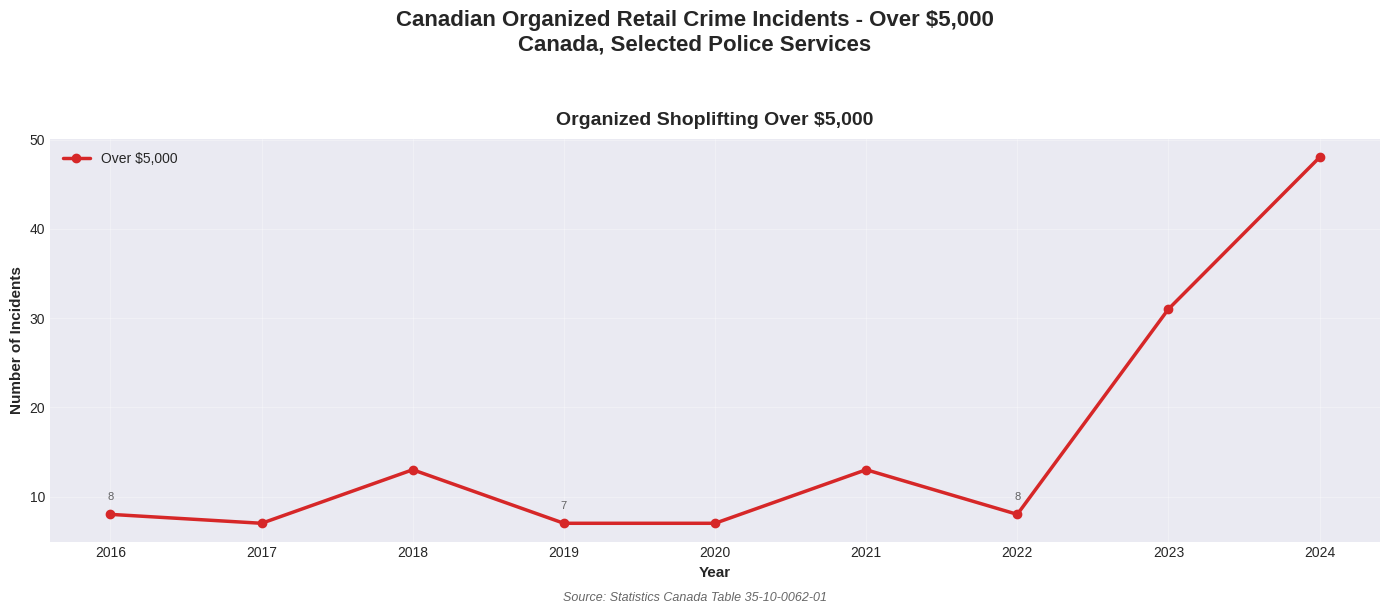

✓ Saved: org_shoplifting_under_5000_trends.png


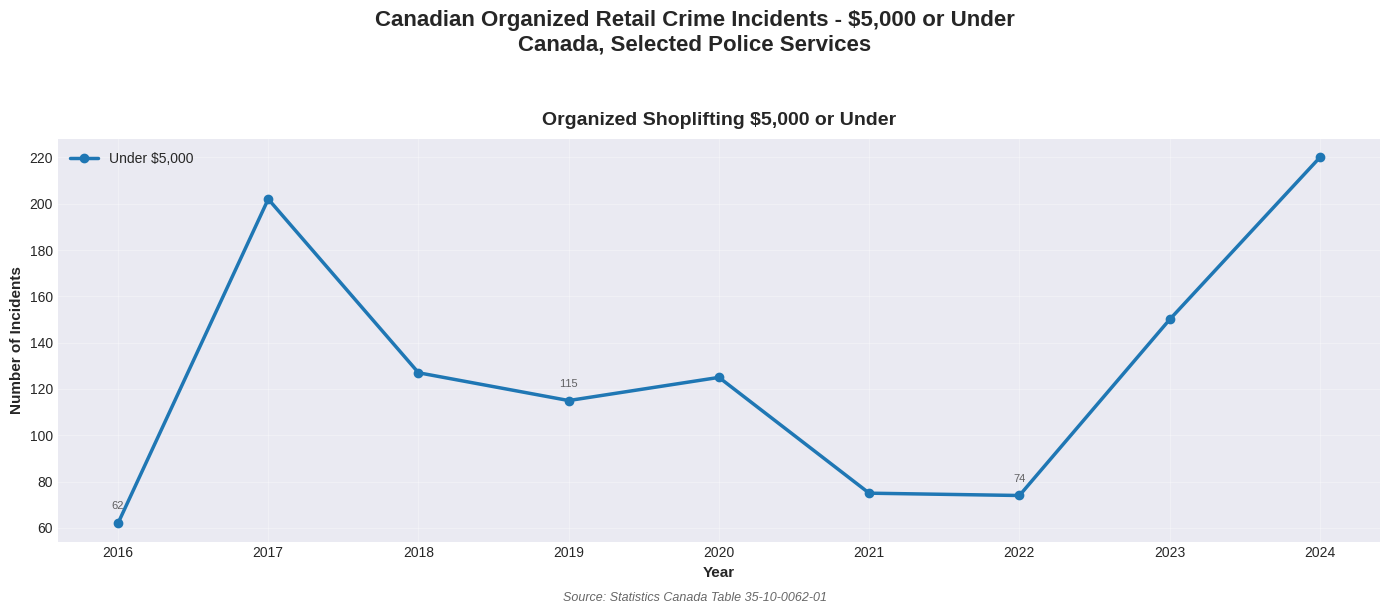

In [ ]:
# Create visualizations
print("\nGenerating visualizations...")

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# Graph 1: Shoplifting Over $5,000
fig1, ax1 = plt.subplots(figsize=(14, 6))
fig1.suptitle('Canadian Organized Retail Crime Incidents - Over $5,000\nCanada, Selected Police Services',
              fontsize=16, fontweight='bold', y=0.995)

ax1.plot(over_5k['Year'], over_5k['Incidents'],
         marker='o', linewidth=2.5, markersize=6, color='#d62728', label='Over $5,000')
ax1.set_title('Organized Shoplifting Over $5,000', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Incidents', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=10)

# Format y-axis with thousands separator
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Add value labels on points
for idx, row in over_5k.iterrows():
    if idx % 3 == 0:  # Label every 3rd point to avoid crowding
        ax1.annotate(f"{int(row['Incidents']):,}",
                    xy=(row['Year'], row['Incidents']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=8, alpha=0.7)

# Add source note for fig1
fig1.text(0.5, 0.01, 'Source: Statistics Canada Table 35-10-0062-01',
          ha='center', fontsize=9, style='italic', alpha=0.7)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig('org_shoplifting_over_5000_trends.png', dpi=300, bbox_inches='tight')
print("✓ Saved: org_shoplifting_over_5000_trends.png")
plt.show()

# Graph 2: Shoplifting Under $5,000
fig2, ax2 = plt.subplots(figsize=(14, 6))
fig2.suptitle('Canadian Organized Retail Crime Incidents - $5,000 or Under\nCanada, Selected Police Services',
              fontsize=16, fontweight='bold', y=0.995)

ax2.plot(under_5k['Year'], under_5k['Incidents'],
         marker='o', linewidth=2.5, markersize=6, color='#1f77b4', label='Under $5,000')
ax2.set_title('Organized Shoplifting $5,000 or Under', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Incidents', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=10)

# Format y-axis with thousands separator
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Add value labels on points
for idx, row in under_5k.iterrows():
    if idx % 3 == 0:  # Label every 3rd point to avoid crowding
        ax2.annotate(f"{int(row['Incidents']):,}",
                    xy=(row['Year'], row['Incidents']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=8, alpha=0.7)

# Add source note for fig2
fig2.text(0.5, 0.01, 'Source: Statistics Canada Table 35-10-0062-01',
          ha='center', fontsize=9, style='italic', alpha=0.7)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig('org_shoplifting_under_5000_trends.png', dpi=300, bbox_inches='tight')
print("✓ Saved: org_shoplifting_under_5000_trends.png")
plt.show()

In [ ]:
# Calculate and display summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\nShoplifting Over $5,000:")
print(f"  Total incidents (all years): {over_5k['Incidents'].sum():,.0f}")
print(f"  Average per year: {over_5k['Incidents'].mean():,.0f}")
print(f"  Highest year: {over_5k.loc[over_5k['Incidents'].idxmax(), 'Year']:.0f} ({over_5k['Incidents'].max():,.0f} incidents)")
print(f"  Lowest year: {over_5k.loc[over_5k['Incidents'].idxmin(), 'Year']:.0f} ({over_5k['Incidents'].min():,.0f} incidents)")

if len(over_5k) > 1:
    first_year = over_5k.iloc[0]['Incidents']
    last_year = over_5k.iloc[-1]['Incidents']
    pct_change = ((last_year - first_year) / first_year) * 100
    print(f"  Change from {over_5k.iloc[0]['Year']:.0f} to {over_5k.iloc[-1]['Year']:.0f}: {pct_change:+.1f}%")

print("\nShoplifting Under $5,000:")
print(f"  Total incidents (all years): {under_5k['Incidents'].sum():,.0f}")
print(f"  Average per year: {under_5k['Incidents'].mean():,.0f}")
print(f"  Highest year: {under_5k.loc[under_5k['Incidents'].idxmax(), 'Year']:.0f} ({under_5k['Incidents'].max():,.0f} incidents)")
print(f"  Lowest year: {under_5k.loc[under_5k['Incidents'].idxmin(), 'Year']:.0f} ({under_5k['Incidents'].min():,.0f} incidents)")

if len(under_5k) > 1:
    first_year = under_5k.iloc[0]['Incidents']
    last_year = under_5k.iloc[-1]['Incidents']
    pct_change = ((last_year - first_year) / first_year) * 100
    print(f"  Change from {under_5k.iloc[0]['Year']:.0f} to {under_5k.iloc[-1]['Year']:.0f}: {pct_change:+.1f}%")

print("\n" + "="*80)
print("Analysis complete!")
print("="*80)


SUMMARY STATISTICS

Shoplifting Over $5,000:
  Total incidents (all years): 142
  Average per year: 16
  Highest year: 2024 (48 incidents)
  Lowest year: 2017 (7 incidents)
  Change from 2016 to 2024: +500.0%

Shoplifting Under $5,000:
  Total incidents (all years): 1,150
  Average per year: 128
  Highest year: 2024 (220 incidents)
  Lowest year: 2016 (62 incidents)
  Change from 2016 to 2024: +254.8%

Analysis complete!


In [ ]:
# SHOPLIFTING CRIME RATE VISUALS
print("="*80)
print("SHOPLIFTING CRIME RATE VISUALS")
print("="*80)
print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Data Source: Statistics Canada Table 35-10-0177-01")
print("Metric: Crime Rate (per 100,000 population)")
print("="*80)
print("\nFetching data from Statistics Canada...")

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
api_url = "https://www150.statcan.gc.ca/t1/wds/rest/getFullTableDownloadCSV/35100177/en"

response = requests.get(api_url, headers=headers, timeout=60)
zip_url = response.json()['object']

zip_response = requests.get(zip_url, headers=headers, timeout=60)
with zipfile.ZipFile(BytesIO(zip_response.content)) as z:
    csv_files = [f for f in z.namelist() if f.endswith('.csv')]
    df_raw = pd.read_csv(z.open(csv_files[0]), low_memory=False)

print(f"✓ Loaded: {len(df_raw):,} rows")
print(f"✓ Columns: {len(df_raw.columns)}")

SHOPLIFTING CRIME RATE VISUALS
Generated: 2025-11-27 14:33:06
Data Source: Statistics Canada Table 35-10-0177-01
Metric: Crime Rate (per 100,000 population)

Fetching data from Statistics Canada...
✓ Loaded: 7,547,238 rows
✓ Columns: 16


In [ ]:
# Data inspection - Display first few rows
print("\nFirst 5 rows of data:")
display(df_raw.head())

# Display column names
print("\nColumn names:")
print(df_raw.columns.tolist())

# Check available statistics types
print("\nAvailable Statistics types:")
print(df_raw['Statistics'].unique())


First 5 rows of data:


,REF_DATE,GEO,DGUID,Violations,Statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1998,Canada,2021A000011124,"Total, all violations [0]",Actual incidents,Number,223,units,0,v44348247,1.1.1,2688540.00,NaN,NaN,NaN,0
1,1998,Canada,2021A000011124,"Total, all violations [0]","Rate per 100,000 population",Rate,257,units,0,v44396346,1.1.2,8915.12,NaN,NaN,NaN,2
2,1998,Canada,2021A000011124,"Total, all violations [0]",Percentage change in rate,Percent,239,units,0,v44391402,1.1.3,NaN,..,NaN,NaN,2
3,1998,Canada,2021A000011124,"Total, all violations [0]",Percentage contribution to the Crime Severity ...,Percent,239,units,0,v1545644596,1.1.17,100.00,NaN,NaN,NaN,2
4,1998,Canada,2021A000011124,"Total, all violations [0]",Unfounded incidents,Number,223,units,0,v1000149311,1.1.15,NaN,..,NaN,NaN,0



Column names:
['REF_DATE', 'GEO', 'DGUID', 'Violations', 'Statistics', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']

Available Statistics types:
['Actual incidents' 'Rate per 100,000 population'
 'Percentage change in rate'
 'Percentage contribution to the Crime Severity Index (CSI)'
 'Unfounded incidents' 'Percent unfounded' 'Total cleared'
 'Cleared by charge' 'Cleared otherwise' 'Total, persons charged'
 'Rate, total persons charged per 100,000 population aged 12 years and over'
 'Total, adult charged'
 'Rate, adult charged per 100,000 population aged 18 years and over'
 'Total, youth charged'
 'Rate, youth charged per 100,000 population aged 12 to 17 years'
 'Total, youth not charged'
 'Rate, youth not charged per 100,000 population aged 12 to 17 years']


In [ ]:
# Filter data for shoplifting crime rates

print("\nFiltering shoplifting crime rate data...")

# Inspect unique values in 'Violations' to find the correct string for 'Shoplifting under $5,000'
print("\nUnique values in 'Violations' column:")
print(df_raw['Violations'].unique())

# Filter for shoplifting under $5,000 - CRIME RATE
df_under_5k = df_raw[
    (df_raw['Violations'].str.contains(r'Shoplifting \$5,000 or under', case=False, na=False)) &
    (df_raw['GEO'] == 'Canada') &
    (df_raw['Statistics'] == 'Rate per 100,000 population')
].copy()

# Filter for shoplifting over $5,000 - CRIME RATE
df_over_5k = df_raw[
    (df_raw['Violations'].str.contains(r'Shoplifting over \$5,000', case=False, na=False)) &
    (df_raw['GEO'] == 'Canada') &
    (df_raw['Statistics'] == 'Rate per 100,000 population')
].copy()

print(f"✓ Shoplifting under $5,000 (crime rate): {len(df_under_5k)} records")
print(f"✓ Shoplifting over $5,000 (crime rate): {len(df_over_5k)} records")


Filtering shoplifting crime rate data...

Unique values in 'Violations' column:
['Total, all violations [0]'
 'Total, all Criminal Code violations (including traffic) [25]'
 'Total, all Criminal Code violations (excluding traffic) [50]'
 'Total violent Criminal Code violations [100]' 'Homicide [110]'
 'Murder, first degree [1110]' 'Murder, second degree [1120]'
 'Manslaughter [1130]' 'Infanticide [1140]'
 'Total other violations causing death [120]'
 'Criminal negligence causing death [1150]'
 'Other related violations causing death [1160]' 'Attempted murder [1210]'
 'Sexual offence which occurred prior to January 4, 1983 [1300]'
 'Sexual assault, level 3, aggravated [1310]'
 'Sexual assault, level 2, weapon or bodily harm [1320]'
 'Sexual assault, level 1 [1330]'
 'Total sexual violations against children [130]'
 'Sexual interference [1345]' 'Invitation to sexual touching [1350]'
 'Sexual exploitation [1355]'
 'Making sexually explicit material available to children [1367]'
 'Parent 

In [ ]:
# Data prep for shoplifting crime rate visualization

print("\nPreparing data for visualization...")

# Prepare data for under $5,000
df_under_5k['REF_DATE'] = pd.to_numeric(df_under_5k['REF_DATE'], errors='coerce')
df_under_5k['VALUE'] = pd.to_numeric(df_under_5k['VALUE'], errors='coerce')
df_under_5k = df_under_5k[(df_under_5k['REF_DATE'] >= 2000) & (df_under_5k['REF_DATE'] <= 2024)]
df_under_5k = df_under_5k.dropna(subset=['REF_DATE', 'VALUE'])
df_under_5k = df_under_5k.sort_values('REF_DATE')

# Prepare data for over $5,000
df_over_5k['REF_DATE'] = pd.to_numeric(df_over_5k['REF_DATE'], errors='coerce')
df_over_5k['VALUE'] = pd.to_numeric(df_over_5k['VALUE'], errors='coerce')
df_over_5k = df_over_5k[(df_over_5k['REF_DATE'] >= 2000) & (df_over_5k['REF_DATE'] <= 2024)]
df_over_5k = df_over_5k.dropna(subset=['REF_DATE', 'VALUE'])
df_over_5k = df_over_5k.sort_values('REF_DATE')

print(f"✓ Under $5,000: {len(df_under_5k)} data points (2000-2024)")
print(f"✓ Over $5,000: {len(df_over_5k)} data points (2000-2024)")


Preparing data for visualization...
✓ Under $5,000: 25 data points (2000-2024)
✓ Over $5,000: 25 data points (2000-2024)


In [ ]:
# Data preview

print("\nShoplifting Under $5,000 - Crime Rate Sample Data:")
display(df_under_5k[['REF_DATE', 'VALUE', 'Violations', 'Statistics']].head(10))

print("\nShoplifting Over $5,000 - Crime Rate Sample Data:")
display(df_over_5k[['REF_DATE', 'VALUE', 'Violations', 'Statistics']].head(10))


Shoplifting Under $5,000 - Crime Rate Sample Data:


,REF_DATE,VALUE,Violations,Statistics
537490,2000,261.86,"Shoplifting $5,000 or under [2143]","Rate per 100,000 population"
805393,2001,257.83,"Shoplifting $5,000 or under [2143]","Rate per 100,000 population"
1073296,2002,257.34,"Shoplifting $5,000 or under [2143]","Rate per 100,000 population"
1341199,2003,270.67,"Shoplifting $5,000 or under [2143]","Rate per 100,000 population"
1609102,2004,239.53,"Shoplifting $5,000 or under [2143]","Rate per 100,000 population"
1877005,2005,237.47,"Shoplifting $5,000 or under [2143]","Rate per 100,000 population"
2144908,2006,245.22,"Shoplifting $5,000 or under [2143]","Rate per 100,000 population"
2412811,2007,233.84,"Shoplifting $5,000 or under [2143]","Rate per 100,000 population"
2680714,2008,238.22,"Shoplifting $5,000 or under [2143]","Rate per 100,000 population"
2948617,2009,276.33,"Shoplifting $5,000 or under [2143]","Rate per 100,000 population"



Shoplifting Over $5,000 - Crime Rate Sample Data:


,REF_DATE,VALUE,Violations,Statistics
537422,2000,1.44,"Shoplifting over $5,000 [2133]","Rate per 100,000 population"
805325,2001,1.06,"Shoplifting over $5,000 [2133]","Rate per 100,000 population"
1073228,2002,0.88,"Shoplifting over $5,000 [2133]","Rate per 100,000 population"
1341131,2003,0.90,"Shoplifting over $5,000 [2133]","Rate per 100,000 population"
1609034,2004,0.69,"Shoplifting over $5,000 [2133]","Rate per 100,000 population"
1876937,2005,0.67,"Shoplifting over $5,000 [2133]","Rate per 100,000 population"
2144840,2006,0.80,"Shoplifting over $5,000 [2133]","Rate per 100,000 population"
2412743,2007,1.03,"Shoplifting over $5,000 [2133]","Rate per 100,000 population"
2680646,2008,1.11,"Shoplifting over $5,000 [2133]","Rate per 100,000 population"
2948549,2009,1.16,"Shoplifting over $5,000 [2133]","Rate per 100,000 population"


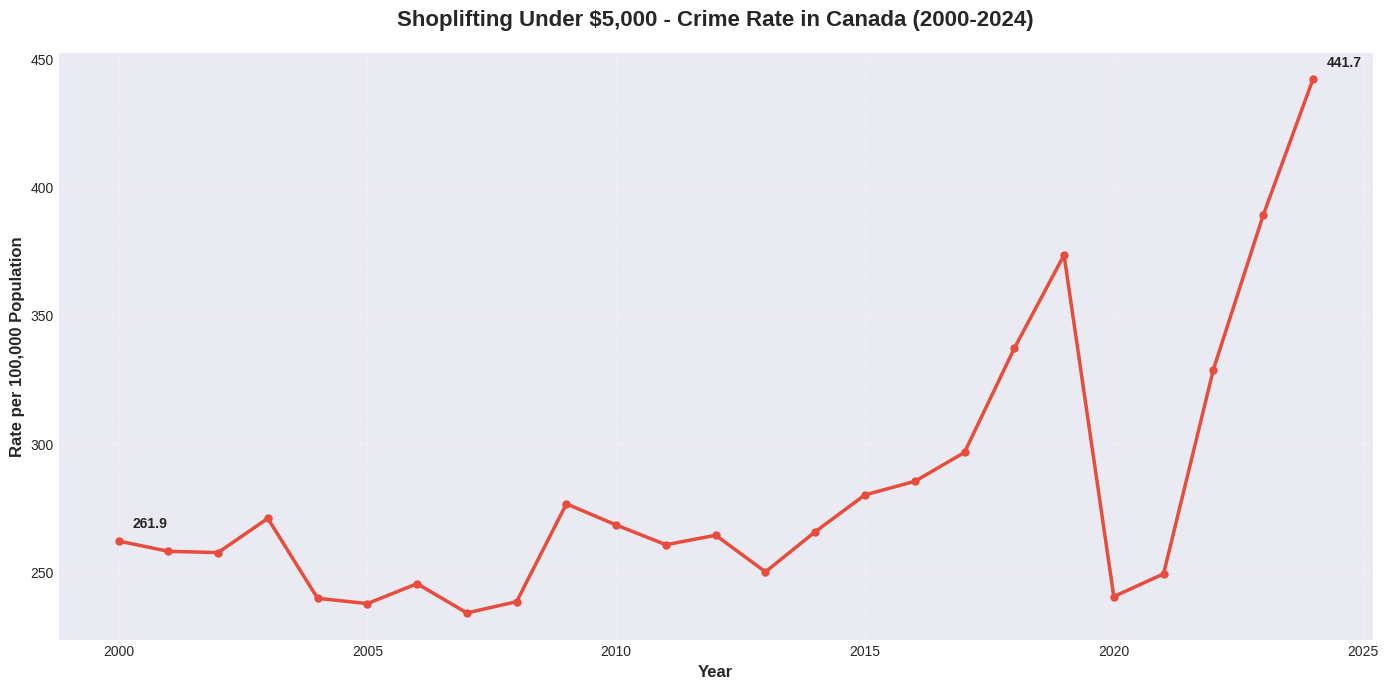


Shoplifting Under $5,000 Crime Rate Summary:
  Range: 2000 - 2024
  Minimum: 233.84 per 100,000
  Maximum: 441.67 per 100,000
  Average: 281.84 per 100,000


In [ ]:
# Visualization shoplifting crime rates under $5,000

plt.figure(figsize=(14, 7))
plt.plot(df_under_5k['REF_DATE'], df_under_5k['VALUE'],
         linewidth=2.5, color='#e74c3c', marker='o', markersize=5)

plt.title('Shoplifting Under $5,000 - Crime Rate in Canada (2000-2024)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Rate per 100,000 Population', fontsize=12, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Add value labels for key years
if len(df_under_5k) > 0:
    min_year = df_under_5k['REF_DATE'].min()
    max_year = df_under_5k['REF_DATE'].max()
    min_val = df_under_5k[df_under_5k['REF_DATE'] == min_year]['VALUE'].values[0]
    max_val = df_under_5k[df_under_5k['REF_DATE'] == max_year]['VALUE'].values[0]

    plt.annotate(f'{min_val:.1f}',
                xy=(min_year, min_val),
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=10, fontweight='bold')
    plt.annotate(f'{max_val:.1f}',
                xy=(max_year, max_val),
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.savefig('shoplifting_under_5k_rate.png') # Save plot as PNG
plt.show()

print(f"\nShoplifting Under $5,000 Crime Rate Summary:")
print(f"  Range: {df_under_5k['REF_DATE'].min():.0f} - {df_under_5k['REF_DATE'].max():.0f}")
print(f"  Minimum: {df_under_5k['VALUE'].min():.2f} per 100,000")
print(f"  Maximum: {df_under_5k['VALUE'].max():.2f} per 100,000")
print(f"  Average: {df_under_5k['VALUE'].mean():.2f} per 100,000")

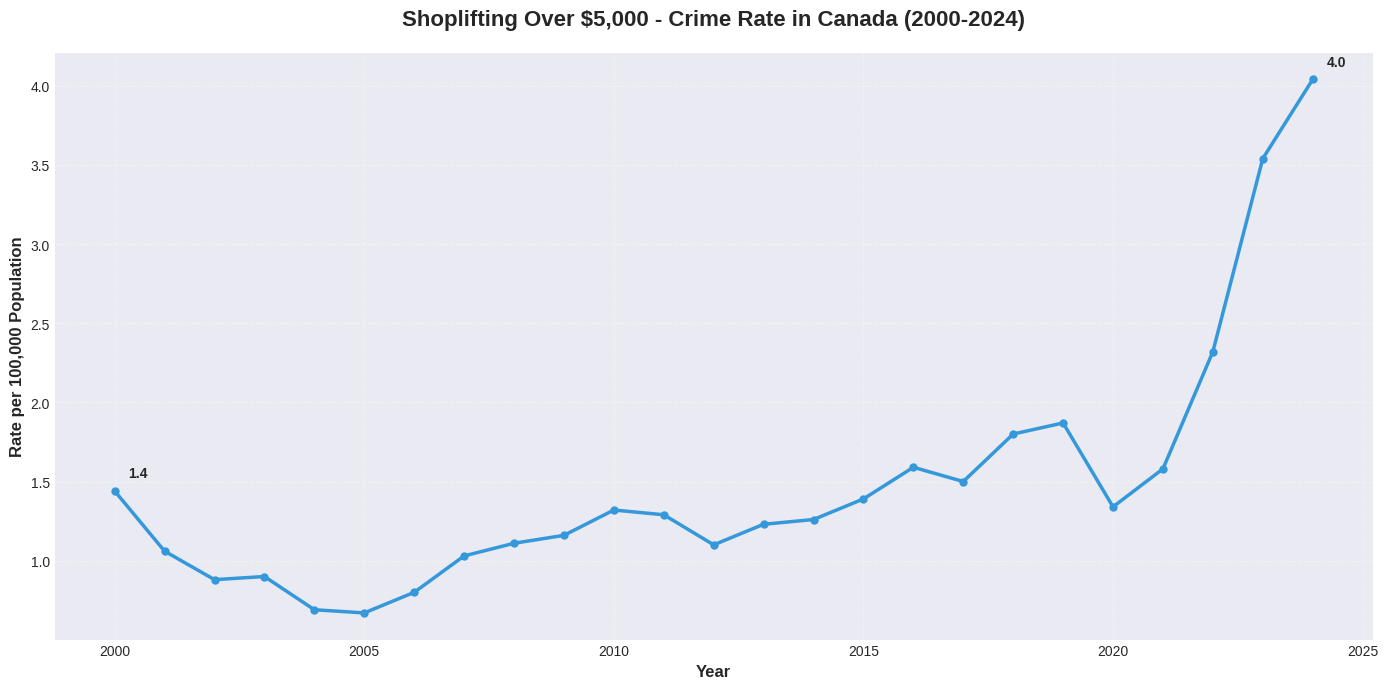


Shoplifting Over $5,000 Crime Rate Summary:
  Range: 2000 - 2024
  Minimum: 0.67 per 100,000
  Maximum: 4.04 per 100,000
  Average: 1.48 per 100,000


In [ ]:
# Viz shoplifting crime rates over $5,000

plt.figure(figsize=(14, 7))
plt.plot(df_over_5k['REF_DATE'], df_over_5k['VALUE'],
         linewidth=2.5, color='#3498db', marker='o', markersize=5)

plt.title('Shoplifting Over $5,000 - Crime Rate in Canada (2000-2024)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Rate per 100,000 Population', fontsize=12, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Add value labels for key years
if len(df_over_5k) > 0:
    min_year = df_over_5k['REF_DATE'].min()
    max_year = df_over_5k['REF_DATE'].max()
    min_val = df_over_5k[df_over_5k['REF_DATE'] == min_year]['VALUE'].values[0]
    max_val = df_over_5k[df_over_5k['REF_DATE'] == max_year]['VALUE'].values[0]

    plt.annotate(f'{min_val:.1f}',
                xy=(min_year, min_val),
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=10, fontweight='bold')
    plt.annotate(f'{max_val:.1f}',
                xy=(max_year, max_val),
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.savefig('shoplifting_over_5k_rate.png') # Save plot as PNG
plt.show()

print(f"\nShoplifting Over $5,000 Crime Rate Summary:")
print(f"  Range: {df_over_5k['REF_DATE'].min():.0f} - {df_over_5k['REF_DATE'].max():.0f}")
print(f"  Minimum: {df_over_5k['VALUE'].min():.2f} per 100,000")
print(f"  Maximum: {df_over_5k['VALUE'].max():.2f} per 100,000")
print(f"  Average: {df_over_5k['VALUE'].mean():.2f} per 100,000")

In [ ]:
# Crime rate growth analyis

print("\nCrime Rate Growth Analysis (First Year vs Last Year):")
print("="*80)

if len(df_under_5k) > 0:
    under_first = df_under_5k.iloc[0]['VALUE']
    under_last = df_under_5k.iloc[-1]['VALUE']
    under_growth = ((under_last - under_first) / under_first) * 100
    under_change = under_last - under_first

    print(f"Shoplifting Under $5,000 Crime Rate:")
    print(f"  {df_under_5k.iloc[0]['REF_DATE']:.0f}: {under_first:.2f} per 100,000")
    print(f"  {df_under_5k.iloc[-1]['REF_DATE']:.0f}: {under_last:.2f} per 100,000")
    print(f"  Change: {under_change:+.2f} per 100,000")
    print(f"  Growth: {under_growth:+.2f}%")
    print()

if len(df_over_5k) > 0:
    over_first = df_over_5k.iloc[0]['VALUE']
    over_last = df_over_5k.iloc[-1]['VALUE']
    over_growth = ((over_last - over_first) / over_first) * 100
    over_change = over_last - over_first

    print(f"Shoplifting Over $5,000 Crime Rate:")
    print(f"  {df_over_5k.iloc[0]['REF_DATE']:.0f}: {over_first:.2f} per 100,000")
    print(f"  {df_over_5k.iloc[-1]['REF_DATE']:.0f}: {over_last:.2f} per 100,000")
    print(f"  Change: {over_change:+.2f} per 100,000")
    print(f"  Growth: {over_growth:+.2f}%")

print("="*80)


Crime Rate Growth Analysis (First Year vs Last Year):
Shoplifting Under $5,000 Crime Rate:
  2000: 261.86 per 100,000
  2024: 441.67 per 100,000
  Change: +179.81 per 100,000
  Growth: +68.67%

Shoplifting Over $5,000 Crime Rate:
  2000: 1.44 per 100,000
  2024: 4.04 per 100,000
  Change: +2.60 per 100,000
  Growth: +180.56%
